<a href="https://colab.research.google.com/github/Angshu001/colab-notebooks/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Support Vector Machine (SVM) with Different Kernels

In [6]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_records = 100
cgpa = np.round(np.random.uniform(5.0, 10.0, n_records), 2)
iq = np.random.randint(80, 140, n_records)
aptitude = np.random.randint(40, 100, n_records)
technical = np.random.randint(40, 100, n_records)
communication = np.random.randint(40, 100, n_records)

score = (cgpa - 5.0) * 10 + (iq - 80) * 0.5 + (aptitude - 40) * 0.3 + (technical - 40) * 0.4 + (communication - 40) * 0.3
placement_probability = 1 / (1 + np.exp(-(score - 45) / 10))
placed = np.where(placement_probability > 0.5, 1, 0)

df = pd.DataFrame({
    'CGPA': cgpa,
    'IQ_Score': iq,
    'Aptitude_Score': aptitude,
    'Technical_Skill_Score': technical,
    'Communication_Skill_Score': communication,
    'Placed': placed
})

print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Records Found:", df.duplicated().sum())

display(df.head())
print(f"Placement Distribution:\n{df['Placed'].value_counts()}")

Missing Values:
 CGPA                         0
IQ_Score                     0
Aptitude_Score               0
Technical_Skill_Score        0
Communication_Skill_Score    0
Placed                       0
dtype: int64

Duplicate Records Found: 0


,CGPA,IQ_Score,Aptitude_Score,Technical_Skill_Score,Communication_Skill_Score,Placed
0,6.87,111,94,85,79,1
1,9.75,118,43,57,72,1
2,8.66,128,94,41,48,1
3,7.99,131,50,93,82,1
4,5.78,111,95,74,93,1


Placement Distribution:
Placed
1    91
0     9
Name: count, dtype: int64


### Task 4-6: Dataset Partitioning & Feature Scaling

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Placed'])
y = df['Placed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Set Shape:", X_train_scaled.shape)
print("Testing Set Shape:", X_test_scaled.shape)

Training Set Shape: (80, 5)
Testing Set Shape: (20, 5)


### Task 7-13: Train and Evaluate SVM Kernels

=== Classification Report for Linear Kernel ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.90      1.00      0.95        18

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20

=== Classification Report for Poly Kernel ===
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.95      1.00      0.97        18

    accuracy                           0.95        20
   macro avg       0.97      0.75      0.82        20
weighted avg       0.95      0.95      0.94        20

=== Classification Report for Rbf Kernel ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.90      1.00      0.95        18

    accuracy                           0.90

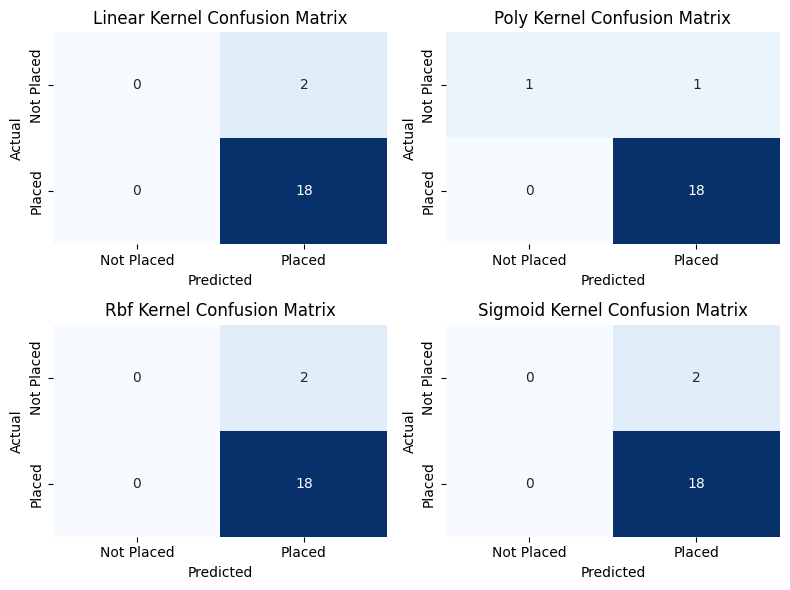

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
models = {}
results = []

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.ravel()

for i, kernel in enumerate(kernels):
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train_scaled, y_train)
    models[kernel] = model

    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        'Kernel': kernel.capitalize(),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"=== Classification Report for {kernel.capitalize()} Kernel ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
    axes[i].set_title(f"{kernel.capitalize()} Kernel Confusion Matrix")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Task 14: Model Comparison & Selection

In [9]:
results_df = pd.DataFrame(results)
display(results_df)

best_row = results_df.sort_values(by=['Accuracy', 'F1-Score'], ascending=False).iloc[0]
best_kernel_name = best_row['Kernel'].lower()
print(f"The best-performing model is the '{best_row['Kernel']}' kernel with {best_row['Accuracy']*100:.2f}% accuracy.")

,Kernel,Accuracy,Precision,Recall,F1-Score
0,Linear,0.90,0.900000,1.0,0.947368
1,Poly,0.95,0.947368,1.0,0.972973
2,Rbf,0.90,0.900000,1.0,0.947368
3,Sigmoid,0.90,0.900000,1.0,0.947368


The best-performing model is the 'Poly' kernel with 95.00% accuracy.


### Task 15-16: Predict Status on 5 New Student Records

In [10]:
new_students = pd.DataFrame([
    [9.2, 130, 95, 90, 88],
    [5.1, 85, 45, 40, 50],
    [8.0, 110, 75, 80, 75],
    [6.5, 90, 60, 55, 60],
    [7.5, 120, 85, 70, 85]
], columns=['CGPA', 'IQ_Score', 'Aptitude_Score', 'Technical_Skill_Score', 'Communication_Skill_Score'])

new_students_scaled = scaler.transform(new_students)

best_model = models[best_kernel_name]
predictions = best_model.predict(new_students_scaled)

new_students['Predicted_Status'] = np.where(predictions == 1, 'Placed', 'Not Placed')
display(new_students)

,CGPA,IQ_Score,Aptitude_Score,Technical_Skill_Score,Communication_Skill_Score,Predicted_Status
0,9.2,130,95,90,88,Placed
1,5.1,85,45,40,50,Not Placed
2,8.0,110,75,80,75,Placed
3,6.5,90,60,55,60,Placed
4,7.5,120,85,70,85,Placed
